# Complete Journey 2.0 Dataset Audit

**Phase 0C — descriptive audit only.** This notebook inspects the `completejourney` 1.1.1 distribution of 84.51° Complete Journey 2.0. It creates no model, clustering, recommendation algorithm, forecast, or return-risk target. Complete Journey is grocery retail data, not e-commerce interaction data.

## 1. Dataset identity and loading

Canonical origin: 84.51° Area 51. Distribution: `completejourney` R package 1.1.1, CC0, maintained at `bradleyboehmke/completejourney`. The package normalizes names to snake_case, converts categorical fields, supplies parsed dates/timestamps, and provides full transactions/promotions separately from built-in samples. Raw RDA/RDS files below are read unchanged.

In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr
from IPython.display import display

pd.set_option('display.max_columns', 100)
RAW = Path('../data/raw/complete_journey')
FILES = sorted([*RAW.glob('*.rda'), *RAW.glob('*.rds')])
assert len(FILES) == 8, f'Expected 8 full tables, found {len(FILES)}'
def read_table(path):
    result = pyreadr.read_r(str(path))
    return next(iter(result.values()))
[(p.name, p.stat().st_size / 1024**2) for p in FILES]

[('campaign_descriptions.rda', 0.0004730224609375),
 ('campaigns.rda', 0.00788116455078125),
 ('coupon_redemptions.rda', 0.007982254028320312),
 ('coupons.rda', 0.30991458892822266),
 ('demographics.rda', 0.004040718078613281),
 ('products.rda', 0.828761100769043),
 ('promotions.rds', 23.819876670837402),
 ('transactions.rds', 12.183819770812988)]

## 2. File/table audit
Every full table is loaded independently. Key duplicates and missingness are reported without altering or dropping rows. Deep memory use reflects the Pandas representation, not compressed raw size.

In [2]:
key_map = {
 'campaign_descriptions': ['campaign_id'], 'campaigns': ['campaign_id','household_id'],
 'coupon_redemptions': ['household_id','coupon_upc','campaign_id','redemption_date'],
 'coupons': ['coupon_upc','product_id','campaign_id'], 'demographics': ['household_id'],
 'products': ['product_id'], 'promotions': ['product_id','store_id','week'],
 'transactions': ['basket_id','product_id'],
}
file_summary, missing_tables = [], {}
for path in FILES:
    name = path.stem; df = read_table(path); keys = key_map[name]
    file_summary.append({'table': name, 'raw_mb': path.stat().st_size/1024**2, 'rows': len(df), 'columns': df.shape[1], 'memory_mb': df.memory_usage(deep=True).sum()/1024**2, 'duplicate_rows': int(df.duplicated().sum()), 'candidate_key': ' + '.join(keys), 'key_duplicate_rows': int(df.duplicated(keys, keep=False).sum())})
    missing_tables[name] = pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing_n': df.isna().sum(), 'missing_pct': df.isna().mean()*100})
    del df; gc.collect()
display(pd.DataFrame(file_summary).round(3))
for name, summary in missing_tables.items(): print(f'\n{name}'); display(summary.round(3))

,table,raw_mb,rows,columns,memory_mb,duplicate_rows,candidate_key,key_duplicate_rows
0,campaign_descriptions,0.000,27,4,0.004,0,campaign_id,0
1,campaigns,0.008,6589,2,0.649,0,campaign_id + household_id,0
2,coupon_redemptions,0.008,2102,4,0.408,0,household_id + coupon_upc + campaign_id + rede...,0
3,coupons,0.310,116204,3,18.469,4872,coupon_upc + product_id + campaign_id,6495
4,demographics,0.004,801,8,0.048,0,household_id,0
5,products,0.829,92331,7,30.232,0,product_id,0
6,promotions,23.820,20940529,5,2275.583,0,product_id + store_id + week,25570
7,transactions,12.184,1469307,11,381.715,0,basket_id + product_id,0



campaign_descriptions


,dtype,missing_n,missing_pct
campaign_id,str,0,0.0
campaign_type,category,0,0.0
start_date,object,0,0.0
end_date,object,0,0.0



campaigns


,dtype,missing_n,missing_pct
campaign_id,str,0,0.0
household_id,str,0,0.0


...

,dtype,missing_n,missing_pct
product_id,str,0,0.000
manufacturer_id,str,0,0.000
department,str,0,0.000
brand,category,0,0.000
product_category,str,540,0.585
product_type,str,528,0.572
package_size,str,30586,33.126



promotions


,dtype,missing_n,missing_pct
product_id,str,0,0.0
store_id,str,0,0.0
display_location,category,0,0.0
mailer_location,category,0,0.0
week,int32,0,0.0



transactions


,dtype,missing_n,missing_pct
household_id,str,0,0.0
store_id,str,0,0.0
basket_id,str,0,0.0
product_id,str,0,0.0
quantity,float64,0,0.0
sales_value,float64,0,0.0
retail_disc,float64,0,0.0
coupon_disc,float64,0,0.0
coupon_match_disc,float64,0,0.0
week,int32,0,0.0


## 3. Grain and relational structure
Grain is validated using key cardinality. Foreign-key mismatches are counted before any join. The promotion and coupon bridges are intentionally many-row structures and must not be joined directly to transactions without aggregation and a time-aware purpose.

In [3]:
names = [p.stem for p in FILES]
small = {n: read_table(RAW / f'{n}.rda') for n in names if (RAW / f'{n}.rda').exists()}
transactions = read_table(RAW/'transactions.rds')
grain = pd.DataFrame([
 ['transactions','one product line within a basket','basket_id + product_id','household_id, store_id, product_id'],
 ['products','one product','product_id','manufacturer_id'],
 ['demographics','one household with available demographics','household_id','none'],
 ['campaigns','one household-campaign assignment','campaign_id + household_id','campaign_id, household_id'],
 ['campaign_descriptions','one campaign','campaign_id','none'],
 ['coupons','one coupon-product-campaign eligibility row','coupon_upc + product_id + campaign_id','product_id, campaign_id'],
 ['coupon_redemptions','one household coupon-redemption record','household_id + coupon_upc + campaign_id + redemption_date','household_id, coupon_upc, campaign_id'],
 ['promotions','one product-store-week placement state','product_id + store_id + week','product_id, store_id'],
], columns=['table','observed_grain','candidate_key','candidate_foreign_keys'])
display(grain)
promotions = read_table(RAW/'promotions.rds')
integrity = pd.Series({
 'unique households in transactions': transactions.household_id.nunique(),
 'unique baskets': transactions.basket_id.nunique(),
 'basket linked to multiple households': transactions.groupby('basket_id').household_id.nunique().gt(1).sum(),
 'basket linked to multiple stores': transactions.groupby('basket_id').store_id.nunique().gt(1).sum(),
 'transaction product unmatched': (~transactions.product_id.isin(small['products'].product_id)).sum(),
 'demographic household absent from transactions': (~small['demographics'].household_id.isin(transactions.household_id)).sum(),
 'campaign household absent from transactions': (~small['campaigns'].household_id.isin(transactions.household_id)).sum(),
 'campaign id unmatched descriptions': (~small['campaigns'].campaign_id.isin(small['campaign_descriptions'].campaign_id)).sum(),
 'coupon product unmatched': (~small['coupons'].product_id.isin(small['products'].product_id)).sum(),
 'coupon campaign unmatched descriptions': (~small['coupons'].campaign_id.isin(small['campaign_descriptions'].campaign_id)).sum(),
 'redemption household absent transactions': (~small['coupon_redemptions'].household_id.isin(transactions.household_id)).sum(),
 'redemption campaign unmatched': (~small['coupon_redemptions'].campaign_id.isin(small['campaign_descriptions'].campaign_id)).sum(),
 'promotion product unmatched': (~promotions.product_id.isin(small['products'].product_id)).sum(),
 'promotion stores absent transactions': (~promotions.store_id.isin(transactions.store_id)).sum(),
})
display(integrity.to_frame('count'))
del promotions; gc.collect()

,table,observed_grain,candidate_key,candidate_foreign_keys
0,transactions,one product line within a basket,basket_id + product_id,"household_id, store_id, product_id"
1,products,one product,product_id,manufacturer_id
2,demographics,one household with available demographics,household_id,none
3,campaigns,one household-campaign assignment,campaign_id + household_id,"campaign_id, household_id"
4,campaign_descriptions,one campaign,campaign_id,none
5,coupons,one coupon-product-campaign eligibility row,coupon_upc + product_id + campaign_id,"product_id, campaign_id"
6,coupon_redemptions,one household coupon-redemption record,household_id + coupon_upc + campaign_id + rede...,"household_id, coupon_upc, campaign_id"
7,promotions,one product-store-week placement state,product_id + store_id + week,"product_id, store_id"


,count
unique households in transactions,2469
unique baskets,155848
basket linked to multiple households,0
basket linked to multiple stores,0
transaction product unmatched,4836
demographic household absent from transactions,0
campaign household absent from transactions,0
campaign id unmatched descriptions,0
coupon product unmatched,16
coupon campaign unmatched descriptions,0


0

## 4. Temporal coverage
Transaction timestamps define actual purchase occasions. Weekly/monthly counts expose boundaries and gaps; customer entry timing is assessed separately from retailer activity.

In [4]:
transactions['transaction_timestamp'] = pd.to_datetime(transactions.transaction_timestamp, errors='coerce')
ts = transactions.transaction_timestamp
basket_times = transactions.groupby(['household_id','basket_id'], as_index=False).agg(transaction_timestamp=('transaction_timestamp','min'), store_id=('store_id','first'))
temporal = pd.Series({'earliest': ts.min(), 'latest': ts.max(), 'duration_days': (ts.max()-ts.min()).days, 'missing_timestamps': ts.isna().sum(), 'transaction_lines': len(transactions), 'distinct_baskets': basket_times.basket_id.nunique(), 'weeks_present': transactions.week.nunique()})
display(temporal.to_frame('value'))
monthly = basket_times.transaction_timestamp.dt.to_period('M').value_counts().sort_index().rename('baskets').to_frame()
weekly = basket_times.transaction_timestamp.dt.to_period('W').value_counts().sort_index().rename('baskets').to_frame()
display(monthly); display(weekly); print('Weeks with zero baskets inside range:', len(pd.period_range(weekly.index.min(), weekly.index.max(), freq='W').difference(weekly.index)))
print('Boundary calendar coverage:', ts.min(), 'through', ts.max())

,value
earliest,2017-01-01 11:53:26
latest,2018-01-01 04:01:20
duration_days,364
missing_timestamps,0
transaction_lines,1469307
distinct_baskets,155848
weeks_present,53


,baskets
transaction_timestamp,
2017-01,12721
2017-02,11787
2017-03,12981
2017-04,12728
2017-05,13663
2017-06,13015
2017-07,13754
2017-08,13419
2017-09,12636


,baskets
transaction_timestamp,
2016-12-26/2017-01-01,298
2017-01-02/2017-01-08,2936
2017-01-09/2017-01-15,2828
2017-01-16/2017-01-22,3007
2017-01-23/2017-01-29,2858
2017-01-30/2017-02-05,3116
2017-02-06/2017-02-12,2866
2017-02-13/2017-02-19,2897
2017-02-20/2017-02-26,2947


Weeks with zero baskets inside range: 0
Boundary calendar coverage: 2017-01-01 11:53:26 through 2018-01-01 04:01:20


## 5. Household purchase depth and inter-purchase behavior
Purchase depth uses distinct baskets. Consecutive intervals use one timestamp per household-basket. Same-day baskets are reported rather than silently merged; no interval is converted into a churn threshold.

,value
households,2469.000000
baskets,155848.000000
exactly 1 basket pct,1.255569
at least 2 pct,98.744431
at least 5 pct,95.139733
at least 10 pct,88.537870
median baskets,43.000000
mean baskets,63.121912
maximum baskets,780.000000


,days
count,153379.000000
mean,5.118022
25%,0.878854
50%,2.209861
75%,5.813177
90%,11.538662
95%,18.069068
99%,45.952194
max,330.762616


,value
same timestamp,84.000000
under 1 day,45742.000000
under 1 day pct,29.822857


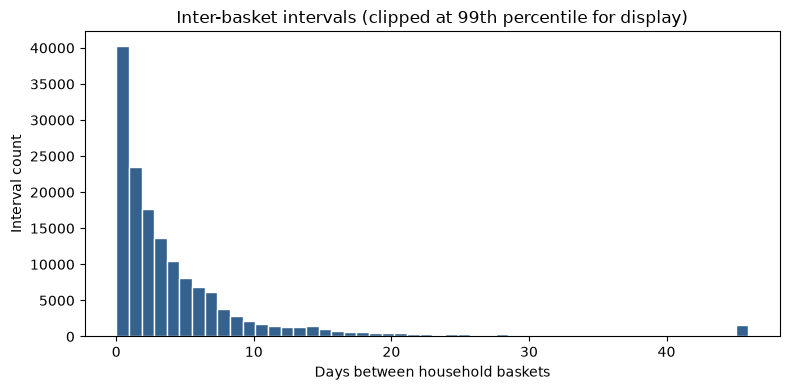

Interpretation: grocery cadence is frequent; same/near-day baskets remain distinct observed occasions and are not churn evidence.


In [5]:
basket_counts = basket_times.groupby('household_id').basket_id.nunique()
purchase_depth = pd.Series({
 'households': basket_counts.size, 'baskets': basket_times.basket_id.nunique(),
 'exactly 1 basket pct': basket_counts.eq(1).mean()*100, 'at least 2 pct': basket_counts.ge(2).mean()*100,
 'at least 5 pct': basket_counts.ge(5).mean()*100, 'at least 10 pct': basket_counts.ge(10).mean()*100,
 'median baskets': basket_counts.median(), 'mean baskets': basket_counts.mean(), 'maximum baskets': basket_counts.max()})
display(purchase_depth.to_frame('value'))
ordered = basket_times.sort_values(['household_id','transaction_timestamp','basket_id'])
intervals = ordered.groupby('household_id').transaction_timestamp.diff().dt.total_seconds().div(86400).dropna()
display(intervals.describe(percentiles=[.25,.5,.75,.9,.95,.99])[['count','mean','25%','50%','75%','90%','95%','99%','max']].to_frame('days'))
display(pd.Series({'same timestamp': intervals.eq(0).sum(), 'under 1 day': intervals.lt(1).sum(), 'under 1 day pct': intervals.lt(1).mean()*100}).to_frame('value'))
fig, ax = plt.subplots(figsize=(8,4)); ax.hist(intervals.clip(upper=intervals.quantile(.99)), bins=50, color='#35618f', edgecolor='white'); ax.set(title='Inter-basket intervals (clipped at 99th percentile for display)', xlabel='Days between household baskets', ylabel='Interval count'); plt.tight_layout(); plt.show()
print('Interpretation: grocery cadence is frequent; same/near-day baskets remain distinct observed occasions and are not churn evidence.')

## 6. Observation depth and right-censoring
First/last purchase, active span, active weeks/months, basket frequency, and follow-up to the dataset end are household-level descriptors. First-purchase cohorts are descriptive and do not define a target.

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
baskets,2469.0,63.121912,69.849892,1.0,9.000000,20.000000,43.0,83.000000,137.000000,182.600000,334.960000,780.0
active_span_days,2469.0,317.447550,74.674346,0.0,227.000000,315.000000,348.0,358.000000,362.000000,363.000000,364.000000,364.0
active_weeks,2469.0,28.201296,15.222245,1.0,7.000000,15.000000,28.0,42.000000,49.000000,51.000000,53.000000,54.0
active_months,2469.0,9.902390,2.953960,1.0,5.000000,9.000000,11.0,12.000000,12.000000,12.000000,13.000000,13.0
baskets_per_active_month,2469.0,5.680204,5.622279,1.0,1.555556,2.285714,4.0,7.083333,11.583333,15.466667,27.913333,65.0
followup_days,2469.0,338.956663,50.883086,3.0,293.000000,343.000000,358.0,362.000000,364.000000,364.000000,364.000000,364.0


,first_month,households,repeat_household_pct,five_plus_pct,max_followup_days,median_followup_days
0,2017-01,1982,99.798184,98.940464,364,360.0
1,2017-02,185,98.918919,91.891892,334,323.0
2,2017-03,113,99.115044,88.495575,306,293.0
3,2017-04,47,97.872340,80.851064,274,264.0
4,2017-05,45,88.888889,71.111111,244,230.0
5,2017-06,21,80.952381,76.190476,214,203.0
6,2017-07,21,90.476190,61.904762,182,171.0
7,2017-08,16,75.000000,62.500000,152,141.0
8,2017-09,16,93.750000,31.250000,121,113.0
9,2017-10,6,83.333333,33.333333,91,82.5


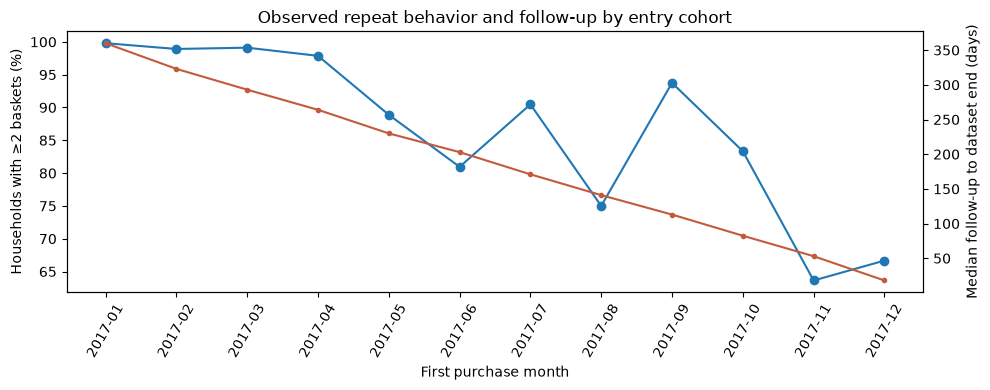

Interpretation: later entrants have less future observation. Only cohorts with a fully available future horizon could enter later supervised snapshots; H is intentionally not chosen here.


In [6]:
obs = ordered.assign(active_week=ordered.transaction_timestamp.dt.to_period('W'), active_month=ordered.transaction_timestamp.dt.to_period('M')).groupby('household_id').agg(first_purchase=('transaction_timestamp','min'), last_purchase=('transaction_timestamp','max'), baskets=('basket_id','nunique'), active_weeks=('active_week','nunique'), active_months=('active_month','nunique'))
dataset_end = ts.max(); obs['active_span_days']=(obs.last_purchase-obs.first_purchase).dt.days; obs['followup_days']=(dataset_end-obs.first_purchase).dt.days; obs['baskets_per_active_month']=obs.baskets/obs.active_months
display(obs[['baskets','active_span_days','active_weeks','active_months','baskets_per_active_month','followup_days']].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).T)
obs['first_month']=obs.first_purchase.dt.to_period('M')
cohorts=obs.groupby('first_month').agg(households=('baskets','size'), repeat_household_pct=('baskets',lambda s:s.ge(2).mean()*100), five_plus_pct=('baskets',lambda s:s.ge(5).mean()*100), max_followup_days=('followup_days','max'), median_followup_days=('followup_days','median')).reset_index()
display(cohorts)
fig, ax1=plt.subplots(figsize=(10,4)); x=cohorts.first_month.astype(str); ax1.plot(x,cohorts.repeat_household_pct,marker='o'); ax1.set(title='Observed repeat behavior and follow-up by entry cohort',xlabel='First purchase month',ylabel='Households with ≥2 baskets (%)'); ax1.tick_params(axis='x',rotation=60); ax2=ax1.twinx(); ax2.plot(x,cohorts.median_followup_days,color='#c45a3c',marker='.'); ax2.set_ylabel('Median follow-up to dataset end (days)'); plt.tight_layout(); plt.show()
print('Interpretation: later entrants have less future observation. Only cohorts with a fully available future horizon could enter later supervised snapshots; H is intentionally not chosen here.')

## 7. Return-risk and segmentation feasibility
A future supervised design could freeze features at snapshot T and ask whether a household returns in a later H, but H and eligibility require further design. Full-history descriptors shown here are not predictive features.

In [7]:
feature_audit=pd.DataFrame([
 ['Recency','Derivable','Relative to snapshot T only'],['Frequency','Derivable','Distinct pre-T baskets'],['Monetary value','Derivable','Pre-T sales_value; discounts have separate semantics'],['Average basket value','Derivable','Aggregate lines to basket first'],['Basket size','Derivable','Quantity/line counts; inspect extreme quantities'],['Unique products','Derivable','Pre-T product diversity'],['Categories/departments','Derivable','Many-to-one product join'],['Brand diversity','Derivable','Product metadata; brand is label class'],['Discount usage','Derivable','Retail/coupon fields before T'],['Coupon usage','Derivable','Redemptions and transaction discounts; avoid campaign many-to-many'],['Promotion sensitivity','Problematic','Exposure joins are product-store-week and observational, not causal'],['Store diversity','Derivable','Distinct pre-T store_id'],['Purchase cadence','Derivable','Intervals available by T only'],['Active span','Derivable','First-to-last purchase by T'],['Demographics','Problematic','Available for only a subset; sensitive/coarse attributes require purpose review'],['Views/cart behavior','Unavailable','Grocery purchase data only'],['Inventory','Unavailable','No on-hand stock or replenishment']], columns=['feature','status','temporal_or_methodological_note'])
display(feature_audit)
print('Snapshot feasibility:', pd.Series({'households spanning >=90 days pct': obs.active_span_days.ge(90).mean()*100, '>=6 active months pct': obs.active_months.ge(6).mean()*100, '>=10 baskets pct': obs.baskets.ge(10).mean()*100, 'demographic coverage pct': transactions.household_id.isin(small['demographics'].household_id).groupby(transactions.household_id).first().mean()*100}))

,feature,status,temporal_or_methodological_note
0,Recency,Derivable,Relative to snapshot T only
1,Frequency,Derivable,Distinct pre-T baskets
2,Monetary value,Derivable,Pre-T sales_value; discounts have separate sem...
3,Average basket value,Derivable,Aggregate lines to basket first
4,Basket size,Derivable,Quantity/line counts; inspect extreme quantities
5,Unique products,Derivable,Pre-T product diversity
6,Categories/departments,Derivable,Many-to-one product join
7,Brand diversity,Derivable,Product metadata; brand is label class
8,Discount usage,Derivable,Retail/coupon fields before T
9,Coupon usage,Derivable,Redemptions and transaction discounts; avoid c...


Snapshot feasibility: households spanning >=90 days pct    96.759822
>=6 active months pct                88.861887
>=10 baskets pct                     88.537870
demographic coverage pct             32.442284
dtype: float64


## 8. Recommendation feasibility
Interactions are distinct household-product purchases. This is purchase-only grocery behavior, unlike RetailRocket's view/cart/transaction funnel. Non-purchase is not a negative signal.

In [8]:
pairs=transactions[['household_id','product_id']].drop_duplicates(); per_hh=pairs.groupby('household_id').product_id.nunique(); per_product=pairs.groupby('product_id').household_id.nunique(); possible=int(pairs.household_id.nunique())*int(pairs.product_id.nunique())
pair_baskets=transactions.groupby(['household_id','product_id']).basket_id.nunique()
rec=pd.Series({'households':pairs.household_id.nunique(),'products':pairs.product_id.nunique(),'distinct interactions':len(pairs),'mean products per household':per_hh.mean(),'median products per household':per_hh.median(),'mean households per product':per_product.mean(),'median households per product':per_product.median(),'matrix sparsity pct':(1-len(pairs)/possible)*100,'multi-product households pct':per_hh.gt(1).mean()*100,'pairs in multiple baskets':pair_baskets.gt(1).sum(),'pairs in multiple baskets pct':pair_baskets.gt(1).mean()*100})
display(rec.to_frame('value'))

,value
households,2469.000000
products,68509.000000
distinct interactions,867688.000000
mean products per household,351.432969
median products per household,277.000000
mean households per product,12.665314
median households per product,2.000000
matrix sparsity pct,99.487027
multi-product households pct,99.756987
pairs in multiple baskets,213604.000000


## 9. Computational feasibility
Raw compressed size, Pandas deep memory, and join multipliers guide implementation choices. Large promotion joins should be filtered/aggregated by week, store, and product before connection to purchases.

In [9]:
resources=pd.DataFrame(file_summary).sort_values('memory_mb',ascending=False); display(resources[['table','raw_mb','rows','memory_mb']].round(2)); print('Total compressed raw MB:',resources.raw_mb.sum()); print('Total estimated deep Pandas MB if all retained:',resources.memory_mb.sum()); print('Transaction-to-product join rows:',len(transactions),'(many-to-one; no row growth expected)'); print('Promotion table must not be directly many-to-many joined to transaction lines without time/store/product aggregation.')

,table,raw_mb,rows,memory_mb
6,promotions,23.82,20940529,2275.58
7,transactions,12.18,1469307,381.72
5,products,0.83,92331,30.23
3,coupons,0.31,116204,18.47
1,campaigns,0.01,6589,0.65
2,coupon_redemptions,0.01,2102,0.41
4,demographics,0.00,801,0.05
0,campaign_descriptions,0.00,27,0.00


Total compressed raw MB: 37.16274929046631
Total estimated deep Pandas MB if all retained: 2707.107074737549
Transaction-to-product join rows: 1469307 (many-to-one; no row growth expected)
Promotion table must not be directly many-to-many joined to transaction lines without time/store/product aggregation.


## Methodological conclusion

Complete Journey supplies repeated household grocery purchases and supports multiple temporal snapshots in principle. A future design could use information available at snapshot T to predict a purchase in a later horizon H, but this audit chooses neither H nor an inactivity threshold. ‘Customer/household return risk’ is more defensible than contractual churn. Observational promotion/discount patterns are not causal effects, descriptive rates are not probabilities, and this grocery-retail source must not be presented as e-commerce behavior.